<a href="https://colab.research.google.com/github/Areej973/BERT-for-Text-Classification-/blob/main/BERT_for_Text_Classification_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT for Text Classification Lab

This lab fine-tunes BERT (distilbert-base-uncased) for multi-class text classification on the Yelp Review dataset (5-star ratings). We use a small subset (10k train, 5k val, 5k test) to fit free Colab T4 GPU limits. The focus is on:
- Preprocessing and tokenizing the dataset.
- Fine-tuning BERT with early stopping and F1-macro for class imbalance.
- Evaluating on a test set with accuracy and F1-macro.

**Setup:** Ensure Runtime > Change runtime type > T4 GPU is enabled.

In [2]:

!pip install transformers datasets torch accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [3]:

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import evaluate
import matplotlib.pyplot as plt

# Set seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

## 1. Load and Preprocess Dataset

We use the yelp_review_full dataset (open-source) from Hugging Face. Labels: 0=1-star, 1=2-star, ..., 4=5-star. Subsample to 20k samples for Colab compatibility.

Train: 10005, Val: 4995, Test: 5000
Train dataset: Dataset({
    features: ['label', 'text'],
    num_rows: 10005
})
Validation dataset: Dataset({
    features: ['label', 'text'],
    num_rows: 4995
})
Test dataset: Dataset({
    features: ['label', 'text'],
    num_rows: 5000
})


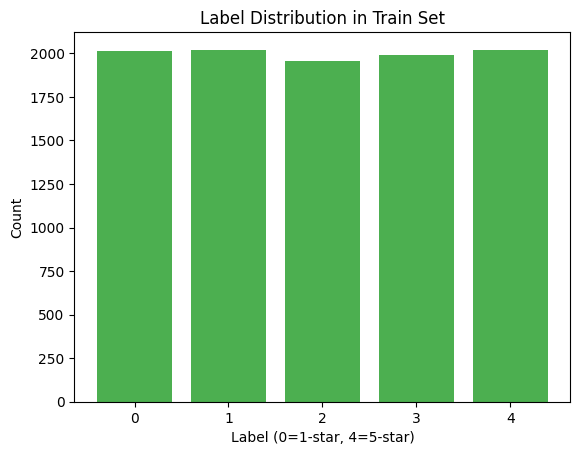

In [7]:
# Load and subsample dataset
dataset = load_dataset("yelp_review_full", split="train")
dataset = dataset.shuffle(seed=42).select(range(20000))

# Convert to list of dicts for sklearn split
data_list = [example for example in dataset]

# Split: 10k train, 5k val, 5k test
train_val_data, test_data = train_test_split(data_list, test_size=0.25, random_state=42)
train_data, val_data = train_test_split(train_val_data, test_size=0.333, random_state=42)

# Convert back to Dataset objects
from datasets import Dataset
train = Dataset.from_list(train_data)
val = Dataset.from_list(val_data)
test = Dataset.from_list(test_data)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print("Train dataset:", train)
print("Validation dataset:", val)
print("Test dataset:", test)

# Visualize label distribution
labels = [example['label'] for example in train]
unique, counts = np.unique(labels, return_counts=True)
plt.bar(unique, counts, color='#4CAF50')
plt.xlabel('Label (0=1-star, 4=5-star)')
plt.ylabel('Count')
plt.title('Label Distribution in Train Set')
plt.show()


## 2. Tokenize Dataset

Tokenize using DistilBERT's tokenizer, truncating to 256 tokens to save memory.

In [9]:
# Load tokenizer
from transformers import AutoTokenizer
from datasets import Dataset
import torch

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
  return tokenizer(examples["text"], truncation=True, max_length=256)

# Verify dataset columns before tokenization
print("Train dataset columns before tokenization:", train.column_names)
print("Validation dataset columns before tokenization:", val.column_names)
print("Test dataset columns before tokenization:", test.column_names)

# Tokenize datasets
train_dataset = train.map(tokenize_function, batched=True)
val_dataset = val.map(tokenize_function, batched=True)
test_dataset = test.map(tokenize_function, batched=True)

# Verify columns after tokenization
print("Train dataset columns after tokenization:", train_dataset.column_names)
print("Validation dataset columns after tokenization:", val_dataset.column_names)
print("Test dataset columns after tokenization:", test_dataset.column_names)

# Rename 'label' to 'labels'
try:
  train_dataset = train_dataset.rename_column("label", "labels")
  val_dataset = val_dataset.rename_column("label", "labels")
  test_dataset = test_dataset.rename_column("label", "labels")
except ValueError:
  print("Error renaming column:",e)
  raise

 # Set format to torch without returning None
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Verify datasets
print("Tokenized train dataset:", train_dataset)
print("Tokenized validation dataset:", val_dataset)
print("Tokenized test dataset:", test_dataset)

# Additional check for dataset contents
print("Sample from train_dataset:", train_dataset[0] if len(train_dataset) > 0 else "Empty dataset")
print("Sample from val_dataset:", val_dataset[0] if len(val_dataset) > 0 else "Empty dataset")
print("Sample from test_dataset:", test_dataset[0] if len(test_dataset) > 0 else "Empty dataset")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train dataset columns before tokenization: ['label', 'text']
Validation dataset columns before tokenization: ['label', 'text']
Test dataset columns before tokenization: ['label', 'text']


Map:   0%|          | 0/10005 [00:00<?, ? examples/s]

Map:   0%|          | 0/4995 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train dataset columns after tokenization: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask']
Validation dataset columns after tokenization: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask']
Test dataset columns after tokenization: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask']
Tokenized train dataset: Dataset({
    features: ['labels', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10005
})
Tokenized validation dataset: Dataset({
    features: ['labels', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4995
})
Tokenized test dataset: Dataset({
    features: ['labels', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5000
})
Sample from train_dataset: {'labels': tensor(3), 'input_ids': tensor([  101,  1996,  4511,  5470, 17592,  2790,  2000,  2031,  1037,  2200,
         2204,  2051,  1010,  1998,  1996,  2717,  1997,  2149,  2018,  1037,
        18243,  7228,  220

## 3. Fine-Tune BERT

Use distilbert-base-uncased (lightweight) with F1-macro to handle class imbalance. Early stopping saves the best model.

In [10]:
# Install required packages
!pip install transformers datasets torch accelerate evaluate scikit-learn

# Import libraries
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import evaluate
import numpy as np

# Load tokenizer (in case it’s not defined)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Load model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5)

# Define metrics (F1-macro for imbalance)
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    }

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Training arguments
training_args = TrainingArguments(
    output_dir="./bert-yelp",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    report_to="none"  # Disable WandB and all external logging
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.997655,0.964932,0.590190,0.580463
2,0.790558,0.940602,0.608008,0.608899
3,0.640642,1.002071,0.614815,0.613829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3753, training_loss=0.8308793476286679, metrics={'train_runtime': 336.461, 'train_samples_per_second': 89.208, 'train_steps_per_second': 11.154, 'total_flos': 1938602645818080.0, 'train_loss': 0.8308793476286679, 'epoch': 3.0})

## 4. Evaluate on Test Set

Compute accuracy and F1-macro on the test set.

In [11]:
# Evaluate
test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)

# Detailed metrics
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average="macro")
print(f"Test Accuracy: {acc:.4f}, Test F1-Macro: {f1:.4f}")

Test Results: {'eval_loss': 1.0162004232406616, 'eval_accuracy': 0.6016, 'eval_f1': 0.6028177108181705, 'eval_runtime': 18.09, 'eval_samples_per_second': 276.396, 'eval_steps_per_second': 34.549, 'epoch': 3.0}
Test Accuracy: 0.6016, Test F1-Macro: 0.6028


## 5. Extensions (Optional)

1. Visualize Errors: Create a confusion matrix to analyze misclassifications.

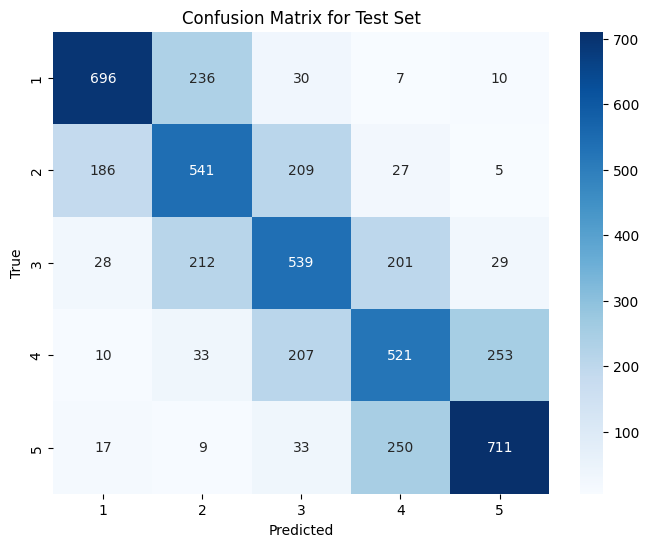

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Predicted rating for sample review: 5-star


In [12]:
# Optional Extensions

# 1. Visualize Errors: Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions and labels from test set
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Compute confusion matrix
cm = confusion_matrix(labels, preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Test Set")
plt.show()

# 2. Save the model for future use
trainer.save_model("./bert-yelp-final")
tokenizer.save_pretrained("./bert-yelp-final")

# 3. Example: Predict on a single review
sample_review = "This restaurant was amazing, great food and service!"
inputs = tokenizer(sample_review, return_tensors="pt", truncation=True, max_length=256)
model = AutoModelForSequenceClassification.from_pretrained("./bert-yelp-final")
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    predicted_class = torch.argmax(outputs.logits, dim=1).item()
print(f"Predicted rating for sample review: {predicted_class + 1}-star")